# Backpropagation — Notes

## 1. Why backpropagation exists

A neural network is a stack of functions. Training means finding weights that minimize a loss function `L`. To minimize `L`, we need `∂L/∂w` for every weight `w` in the network — the gradient tells us which direction to nudge each weight.

Backpropagation is just an efficient way to compute **all** these partial derivatives using the **chain rule**, by reusing intermediate results instead of recomputing them from scratch for every weight.

---

## 2. Setup — a simple network

Take a 2-layer network (1 hidden layer):

```
Input x → [Linear: z1 = W1·x + b1] → [Activation: a1 = f(z1)]
        → [Linear: z2 = W2·a1 + b2] → [Activation: ŷ = f(z2)]
        → Loss: L = loss(ŷ, y)
```

**Forward pass** = compute `z1, a1, z2, ŷ, L` in order, left to right.
**Backward pass** = compute gradients `∂L/∂W2, ∂L/∂b2, ∂L/∂W1, ∂L/∂b1` in order, right to left.

---

## 3. The chain rule — the entire idea in one line

If `L` depends on `ŷ`, and `ŷ` depends on `z2`, and `z2` depends on `W2`:

```
∂L/∂W2 = (∂L/∂ŷ) · (∂ŷ/∂z2) · (∂z2/∂W2)
```

Backprop computes this right to left, and **caches** each factor so it can be reused for the next layer back. That reuse is the entire efficiency trick — without it, you'd redo the same computation exponentially many times per weight.

---

## 4. Step-by-step derivation (output layer first)

**Step 1 — Loss gradient w.r.t. output**
```
δ2 = ∂L/∂ŷ · ∂ŷ/∂z2        (this is often called the "error signal" at layer 2)
```
For MSE loss + sigmoid output, this simplifies nicely. For softmax + cross-entropy, `δ2 = ŷ − y` (a famously clean result — worth memorizing).

**Step 2 — Gradients for layer 2's parameters**
```
∂L/∂W2 = δ2 · a1ᵀ
∂L/∂b2 = δ2
```
Makes sense: the gradient w.r.t. a weight connecting `a1 → z2` scales with how active `a1` was.

**Step 3 — Propagate error backward to layer 1**
```
δ1 = (W2ᵀ · δ2) ⊙ f'(z1)
```
This is the key step — the error signal `δ2` gets "redistributed" backward through `W2`, then multiplied by the local derivative of layer 1's activation function. `⊙` = element-wise multiply.

**Step 4 — Gradients for layer 1's parameters**
```
∂L/∂W1 = δ1 · xᵀ
∂L/∂b1 = δ1
```

**Step 5 — Update weights** (gradient descent)
```
W ← W − η · ∂L/∂W
```
where `η` is the learning rate.

---

## 5. The general pattern (any depth)

For layer `l`, once you know `δ(l+1)` (the error signal one layer ahead):
```
δl = (W(l+1)ᵀ · δ(l+1)) ⊙ f'(zl)
∂L/∂Wl = δl · a(l−1)ᵀ
∂L/∂bl = δl
```
This is why it's called *back*-propagation — you compute `δ` starting from the output layer and walk backward, one layer at a time, each layer's `δ` depending only on the next layer's `δ`.

---

## 6. Why this matters practically

- **Vanishing gradients**: if `f'(z)` is small (e.g. sigmoid saturates near 0 or 1), `δ` shrinks every layer you go back — deep networks stop learning in early layers. This is *why* ReLU exists (its derivative is 1 for all positive `z`, so it doesn't shrink gradients).
- **Exploding gradients**: if weights are large, `δ` can blow up going backward — this is why weight initialization (Xavier/He) and gradient clipping matter.
- **Autograd (PyTorch/TensorFlow)** does exactly this automatically — it builds a computation graph during the forward pass and walks it backward applying the chain rule. Understanding this by hand is *why* `loss.backward()` isn't magic.

---

## 7. Quick self-check

If you can answer these without looking, you understand it:
1. Why is `δ2 = ŷ − y` for softmax + cross-entropy? (Try deriving it.)
2. Why does `∂L/∂W1` depend on `x`, but `∂L/∂W2` depends on `a1`?
3. What happens to `δ1` if `f'(z1) = 0` everywhere (dead ReLU)?
4. Why does batch size affect the gradient (hint: loss is usually averaged over the batch)?

---

## 8. Suggested exercise (ties into your "math before framework" approach)

Implement steps 1–5 above in raw NumPy for a 2-layer network on a toy dataset (XOR or a small synthetic set). No `autograd`, no framework — compute every `δ`, every gradient, and the update step by hand. Once this works, switch to PyTorch/Keras and verify your manual gradients match `loss.backward()` — that's the real proof you understand it.

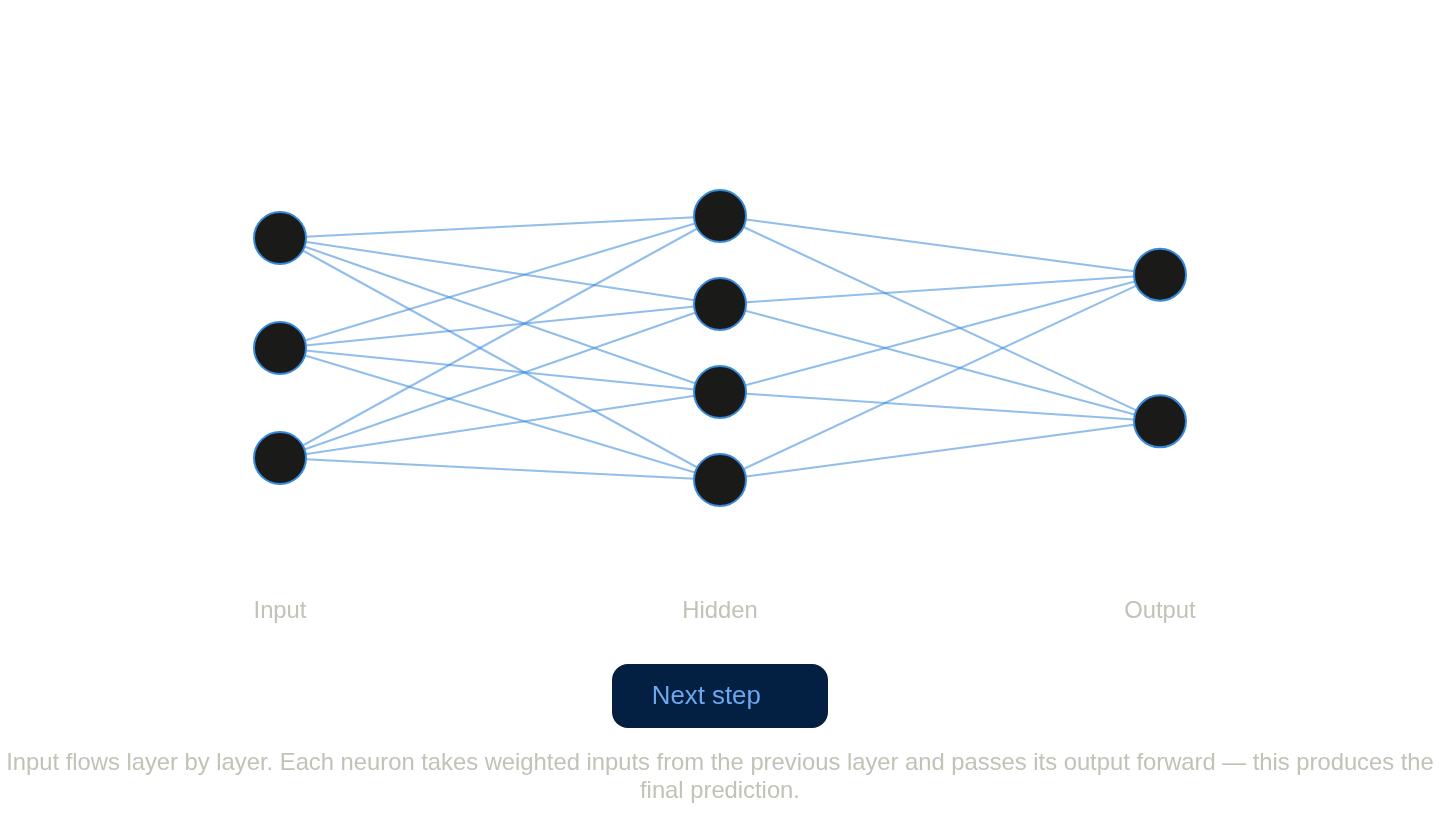

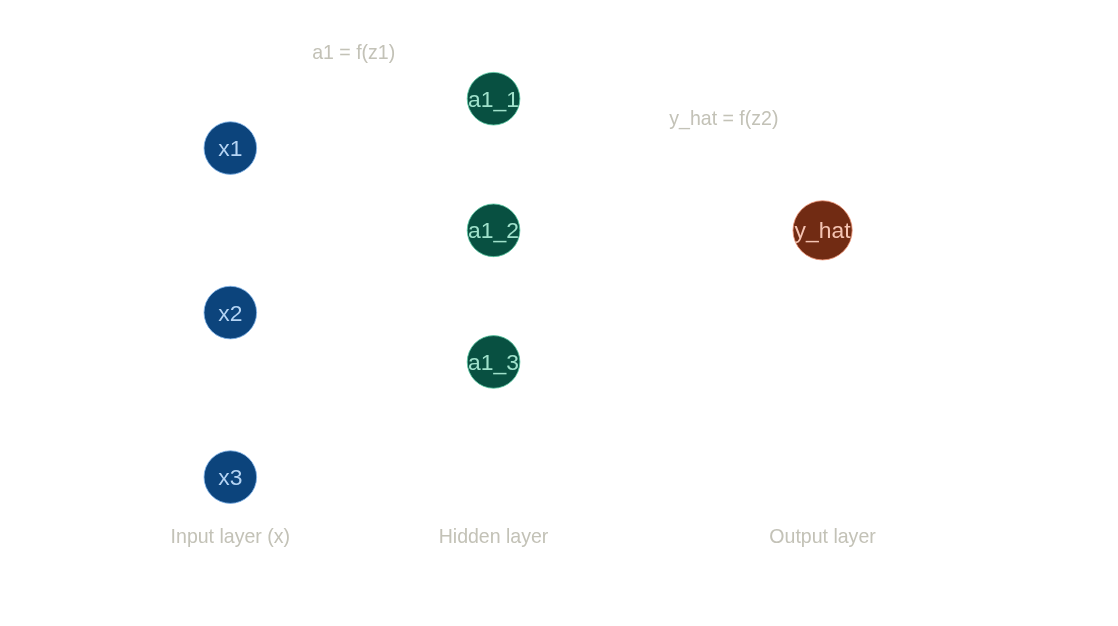